In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10
from keras.models  import Sequential
from keras.layers import LSTM, Dropout, Dense
from sklearn.preprocessing import MinMaxScaler

In [42]:
df = pd.read_csv(r"C:\Users\MY LAPTOP\OneDrive\Desktop\Machine_Learning\Stock Price Prediction\NSE-Tata-Global-Beverages-Limited.csv")

In [43]:
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


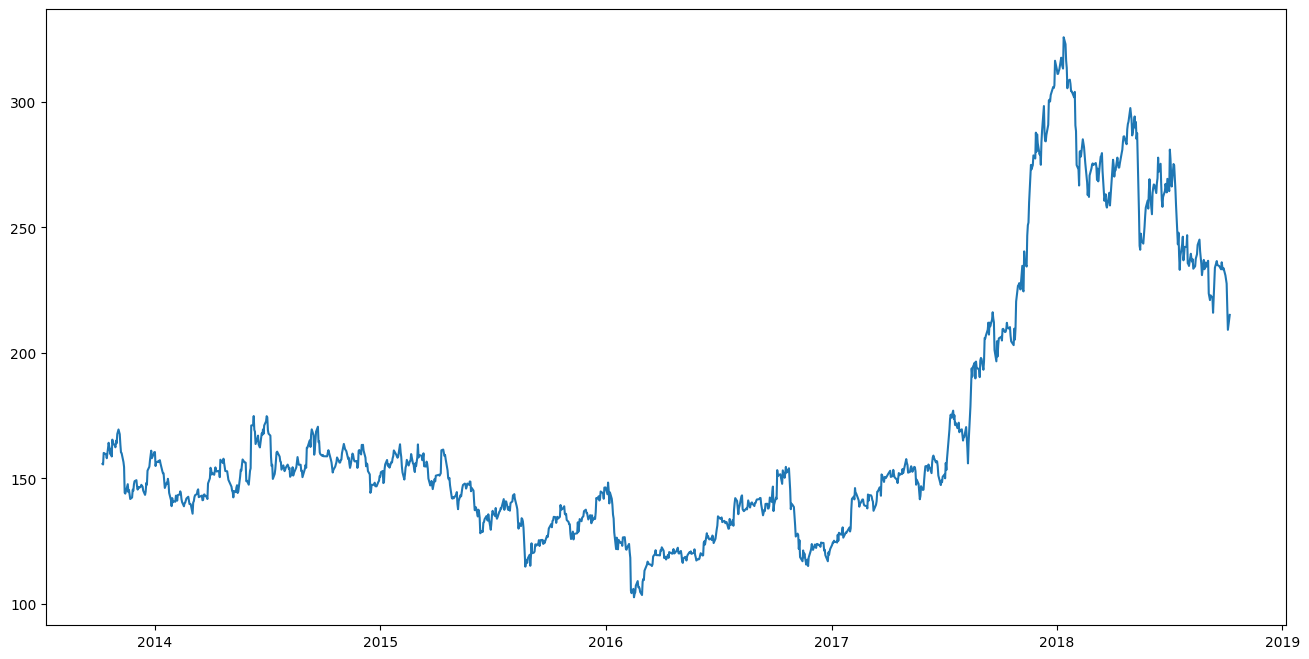

In [44]:
df['Date'] = pd.to_datetime(df.Date, format="%Y-%m-%d")
df.index = df['Date']


plt.figure(figsize=(16,8))
plt.plot(df['Close'], label="Close Price History")

In [45]:
data = df.sort_index(ascending=True, axis=0)
new_dataset = pd.DataFrame(index=range(0, len(df)), columns=['Date', 'Close'])

for i in range (0, len(data)):
    new_dataset['Date'][i]=data['Date'][i]
    new_dataset['Close'][i]=data['Close'][i]

C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\3032547119.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  new_dataset['Date'][i]=data['Date'][i]
C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\3032547119.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the ass

In [46]:
scaler = MinMaxScaler(feature_range=(0,1))

new_dataset.drop('Date', axis=1, inplace=True)

final_dataset = new_dataset[['Close']].values

train_data = final_dataset[0:987, :]
valid_data = final_dataset[987:, :]

new_dataset.index = new_dataset.Date
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(final_dataset)

X_train_data, y_train_data = [], []

for i  in range(60, len(train_data)):
    X_train_data.append(scaled_data[i-60: i, 0])
    y_train_data.append(scaled_data[i, 0])

X_train_data, y_train_data = np.array(X_train_data), np.array(y_train_data)
X_train_data = np.reshape(X_train_data, (X_train_data.shape[0], X_train_data.shape[1], [1]))

AttributeError: 'DataFrame' object has no attribute 'Date'

In [37]:
new_dataset

,Close
Date,
2013-10-08,155.8
2013-10-09,155.55
2013-10-10,160.15
2013-10-11,160.05
2013-10-14,159.45
...,...
2018-10-01,230.9
2018-10-03,227.6
2018-10-04,218.2
